# 01 - Synthetic Data Generation

CRED Market Entry and Segmentation Diagnostic - Shashank Tiwari, IIT Kharagpur

In [1]:
import sys, warnings, logging
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import config
from src.utils import setup_logging
setup_logging(logging.INFO)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
FIG = config.FIGURES_DIR

## Why synthetic?
No public row-level Indian credit-card data exists. We synthesise a 200K-card sample whose marginals follow RBI / CIBIL / NPCI headline patterns (119M cards, ~3.1 cards per holder, 65/35 gender skew, Tier-1 concentration) and embed **six latent behavioural archetypes** so that segmentation has a recoverable structure.

In [2]:
from src.data_generator import generate_credit_card_data, TOP_50_CITIES
cards, panel = generate_credit_card_data(n_cards=config.N_CARDS, save=False)
cards.head()

04:50:39 | INFO    | cred.data_generator | Generating 200,000 synthetic card records (scaled to 119M real cards)


04:50:43 | INFO    | cred.data_generator | Total cards: 200,000 | unique holders: 64,086 | avg cards/holder: 3.12


04:50:43 | INFO    | cred.data_generator | Income (lakhs) - mean 23.5 | median 18.8 | p90 44.8 | max 172.5


04:50:43 | INFO    | cred.data_generator | Archetype mix: {'Conservative Savers': 0.201, 'Reward Chasers': 0.199, 'Digital-First': 0.153, 'Premium High-Spenders': 0.149, 'Revolvers': 0.149, 'EMI-Dependent': 0.149}


04:50:43 | INFO    | cred.data_generator | Panel: 1,538,064 rows across 24 months


,card_id,holder_id,holder_name,age,gender,city_tier,city,state,annual_income_lakhs,credit_score,card_type,card_issuer,card_limit_lakhs,avg_monthly_spend,avg_monthly_repayment_pct,months_active,num_cards,upi_credit_usage,has_emi_active,missed_payments_12m,reward_redemption_rate,digital_transaction_pct,latent_archetype
0,00000000-0000-0000-5add-e63a63d9e99d,H0000000,Kashish Saraf,21,Female,Tier-1,Chennai,Tamil Nadu,11.27,705,Rewards,Others,1.096,2183.65,0.7930,92,5,0.6475,False,0,0.4925,0.8929,Digital-First
1,00000000-0000-0000-4d1c-bfb35780799b,H0000000,Kashish Saraf,21,Female,Tier-1,Chennai,Tamil Nadu,11.27,705,Rewards,Others,1.767,3409.51,0.7705,90,5,0.7149,False,0,0.3902,0.9426,Digital-First
2,00000000-0000-0000-3e58-c9bd3406abd1,H0000000,Kashish Saraf,21,Female,Tier-1,Chennai,Tamil Nadu,11.27,705,Rewards,Others,1.062,2011.95,0.7295,103,5,0.7422,False,0,0.4968,0.951,Digital-First
3,00000000-0000-0000-2ff3-8197f7c2c123,H0000000,Kashish Saraf,21,Female,Tier-1,Chennai,Tamil Nadu,11.27,705,Basic,Kotak,1.507,2286.27,0.7773,73,5,0.8132,False,0,0.4729,1.0,Digital-First
4,00000000-0000-0000-1497-ddf64cea2170,H0000000,Kashish Saraf,21,Female,Tier-1,Chennai,Tamil Nadu,11.27,705,Rewards,HDFC,1.371,1979.89,0.7637,100,5,0.9066,False,0,0.4136,0.9604,Digital-First


### Archetype design
Every holder is drawn from one of six archetypes; behavioural traits (repayment, UPI credit, reward redemption, digital share, EMI, delinquency) are holder-level and each card jitters around them.

In [3]:
pd.DataFrame(config.ARCHETYPES).T[['share','income_mult','score_shift','repay','upi','reward','emi_prob','missed_prob','premium_prob','cards_lambda']]

,share,income_mult,score_shift,repay,upi,reward,emi_prob,missed_prob,premium_prob,cards_lambda
Premium High-Spenders,0.15,2.60,55.0,0.90,0.08,0.30,0.05,0.03,0.97,2.0
Reward Chasers,0.20,0.95,15.0,0.78,0.25,0.90,0.08,0.04,0.25,5.5
EMI-Dependent,0.15,0.80,-15.0,0.60,0.15,0.20,0.97,0.25,0.03,1.3
Conservative Savers,0.20,1.00,35.0,0.96,0.06,0.12,0.03,0.02,0.03,0.1
Digital-First,0.15,0.85,0.0,0.72,0.78,0.50,0.10,0.08,0.05,1.7
Revolvers,0.15,0.75,-95.0,0.22,0.35,0.20,0.12,0.97,0.03,2.2


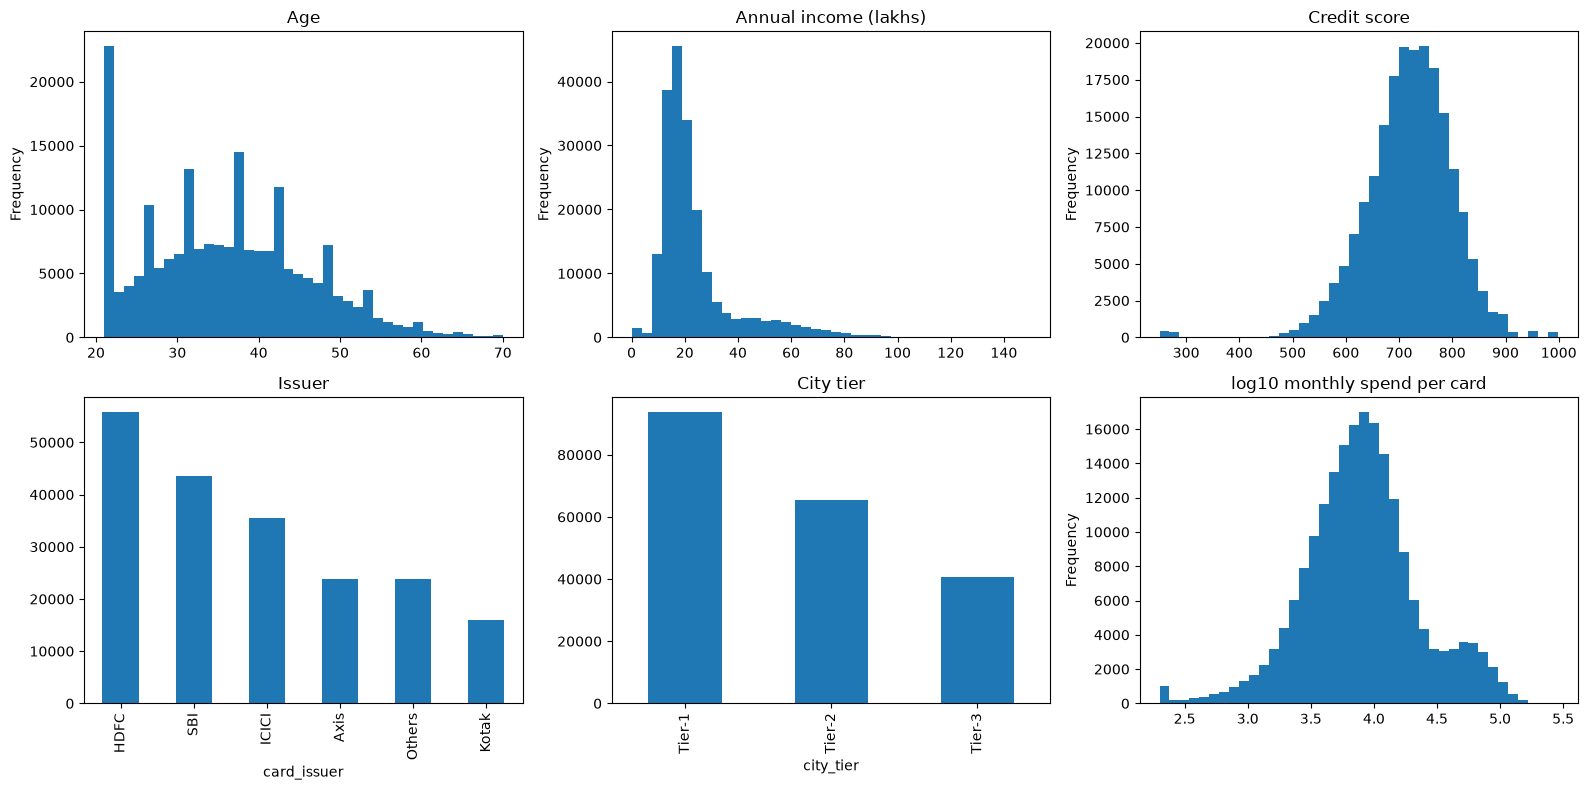

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
num = pd.to_numeric
num(cards['age'], errors='coerce').plot.hist(bins=40, ax=axes[0,0], title='Age')
num(cards['annual_income_lakhs'], errors='coerce').clip(upper=150).plot.hist(bins=40, ax=axes[0,1], title='Annual income (lakhs)')
cards['credit_score'].plot.hist(bins=40, ax=axes[0,2], title='Credit score')
cards['card_issuer'].value_counts().plot.bar(ax=axes[1,0], title='Issuer')
cards['city_tier'].value_counts().plot.bar(ax=axes[1,1], title='City tier')
np.log10(cards['avg_monthly_spend']).plot.hist(bins=40, ax=axes[1,2], title='log10 monthly spend per card')
plt.tight_layout()

### Seasonality in the 24-month panel
Diwali (Oct-Nov) 1.35-1.45x, December 1.2x, January 0.8x, March 1.1x, plus ~15% YoY growth and a mildly persistent macro shock.

Text(0, 0.5, 'INR M')

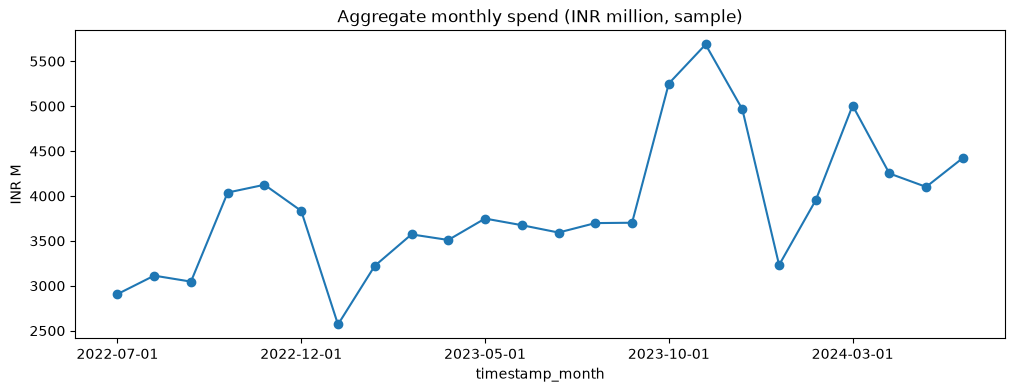

In [5]:
s = panel.groupby('timestamp_month')['monthly_spend'].sum() / 1e6
ax = s.plot(figsize=(12, 4), marker='o', title='Aggregate monthly spend (INR million, sample)')
ax.set_ylabel('INR M')

In [6]:
print(f"cards={len(cards):,} holders={cards['holder_id'].nunique():,} avg cards/holder={len(cards)/cards['holder_id'].nunique():.2f}")
print('null share by column (injected noise):'); cards.isna().mean()[lambda s: s > 0].round(4)

cards=200,000 holders=64,086 avg cards/holder=3.12
null share by column (injected noise):


age                        0.0076
gender                     0.0076
city                       0.0074
annual_income_lakhs        0.0077
card_type                  0.0072
card_issuer                0.0076
months_active              0.0073
upi_credit_usage           0.0075
reward_redemption_rate     0.0076
digital_transaction_pct    0.0074
dtype: float64